In [1]:
import torch
from d2l import torch as d2l
import random

In [98]:
## 测试矩阵分块乘法
X =  torch.normal(0,1,(3,1))
W_xh = torch.normal(0,1,(1,4))
H = torch.normal(0,1,(3,4))
W_hh = torch.normal(0,1,(4,4))

In [99]:
torch.matmul(X,W_xh) + torch.matmul(H,W_hh)

tensor([[-0.4697,  0.7189,  0.0686,  2.2423],
        [ 0.3539,  0.8072, -0.4146,  1.2411],
        [ 1.8020, -1.2174,  0.4782,  6.7356]])

In [100]:
torch.matmul(torch.cat((X,H),1),torch.cat((W_xh,W_hh),0))

tensor([[-0.4697,  0.7189,  0.0686,  2.2423],
        [ 0.3539,  0.8072, -0.4146,  1.2411],
        [ 1.8020, -1.2174,  0.4782,  6.7356]])

In [101]:
%matplotlib inline
import math
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

In [102]:
import collections
import re
import os
import hashlib
import requests

# 1. 下载并读取《时光机器》数据集
def read_time_machine():
    # 下载数据集
    url = 'http://d2l-data.s3-accelerate.amazonaws.com/timemachine.txt'
    file_path = 'timemachine.txt'
    if not os.path.exists(file_path):
        print("正在下载《时光机器》数据集...")
        r = requests.get(url)
        with open(file_path, 'wb') as f:
            f.write(r.content)
    
    # 读取并预处理（转为小写，去除非字母字符）
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    return [re.sub('[^A-Za-z]+', ' ', line).strip().lower() for line in lines]

# 2. 词元化（按字符或单词拆分）
def tokenize(lines, token='word'):
    if token == 'word':
        return [line.split() for line in lines]
    elif token == 'char':
        return [list(line) for line in lines]
    else:
        print('错误：未知词元类型：' + token)

# 3. 构建词表类
class Vocab:
    def __init__(self, tokens=None):
        self.idx_to_token = []
        self.token_to_idx = dict()
        if tokens is not None:
            if tokens and isinstance(tokens[0], list):
                # 如果是二维列表，展平它
                tokens = [token for line in tokens for token in line]
            # 统计词频并按频率排序
            counter = collections.Counter(tokens)
            self.idx_to_token = sorted(counter, key=counter.get, reverse=True)
            self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if not isinstance(indices, (list, tuple)):
            return self.idx_to_token[indices]
        return [self.idx_to_token[index] for index in indices]

    @property
    def unk(self):  # 未知词元的索引为0
        return 0

# 4. 将上述功能组合成 load_corpus_time_machine
def load_corpus_time_machine(max_tokens=-1):
    """返回时光机器数据集的词元索引列表和词表"""
    lines = read_time_machine()
    # 这里默认使用字符级词元化
    tokens = tokenize(lines, 'char')
    vocab = Vocab(tokens)
    # 因为时光机器数据集中的每个文本行不一定是一个句子或一个段落，
    # 所以将所有文本行展平到一个列表中
    corpus = [vocab[token] for line in tokens for token in line]
    if max_tokens > 0:
        corpus = corpus[:max_tokens]
    return corpus, vocab

In [103]:
tokens = d2l.tokenize(read_time_machine())
corpus = [token for line in tokens for token in line]
vocab = d2l.Vocab(corpus)
vocab.token_freqs[:10]

[('the', 2261),
 ('i', 1267),
 ('and', 1245),
 ('of', 1155),
 ('a', 816),
 ('to', 695),
 ('was', 552),
 ('in', 541),
 ('that', 443),
 ('my', 440)]

In [104]:
## random subsampling, 保证coverage 和 randomness
def  seq_data_iter_random(corpus,batch_size,num_steps):
    ## 随机确定offset
    corpus = corpus[random.randint(0,num_steps-1):]
    ## 计算subseq的数量，需要减1再向下取整
    num_subseqs = (len(corpus) - 1) // num_steps
    ## 确定每个subseq和初始索引
    initial_indices = list(range(0,num_steps*num_subseqs,num_steps))
    ## 随机化
    random.shuffle(initial_indices)

    def data(pos):
        return corpus[pos:pos+num_steps]
    num_batches = num_subseqs // batch_size
    for i in range (0,num_batches*batch_size,batch_size):
        initial_indices_per_batch = initial_indices[i:i+batch_size]
        X = [data(j) for j in initial_indices_per_batch]
        Y = [data(j+1) for j in initial_indices_per_batch]
        yield torch.tensor(X), torch.tensor(Y)

In [105]:
def seq_data_iter_sequential(corpus,batch_size,num_steps):
    offset = random.randint(0,num_steps)
    num_tokens = ((len(corpus) - offset -1)// batch_size) * batch_size
    Xs = torch.tensor(corpus[offset:offset+num_tokens])
    Ys = torch.tensor(corpus[offset+1:offset+1+num_tokens])
    Xs = Xs.reshape(batch_size,-1)
    Ys = Ys.reshape(batch_size,-1)
    num_batches = Xs.shape[1] // num_steps
    for  i in range(0,num_steps*num_batches,num_steps):
        X = Xs[:,i:i+num_steps]
        Y = Ys[:,i:i+ num_steps]
        yield X,Y

In [106]:
class SeqDataLoader: #@svae
    def __init__(self,batch_size,num_steps,use_random_iter,max_tokens):
        if use_random_iter:
            self.data_iter_fn = seq_data_iter_random
        else:
            self.data_iter_fn = seq_data_iter_sequential
        self.corpus,self.vocab = load_corpus_time_machine(max_tokens)
        self.batch_size,self.num_steps = batch_size,num_steps
    def __iter__(self):
        return self.data_iter_fn(self.corpus,self.batch_size,self.num_steps)

    

In [107]:
def load_data_time_machine(batch_size,num_steps,use_random_iter=False,max_tokens=10000): #@save
    data_iter = SeqDataLoader(
        batch_size,num_steps,use_random_iter,max_tokens
    )
    return data_iter,data_iter.vocab

In [108]:
batch_size, num_steps = 32, 35
train_iter, vocab = load_data_time_machine(batch_size, num_steps)

In [109]:
## one_hot encoding transpose X 
X = torch.arange(10).reshape((2,5))
F.one_hot(X.T,28).shape

torch.Size([5, 2, 28])

In [110]:
## parameter initialization
def get_params(vocab_size,num_hiddens,device):
    num_inputs = num_outputs = vocab_size
    def normal(shape):
        return torch.randn(size=shape,device=device)*0.01
    W_xh = normal((num_inputs,num_hiddens))
    W_hh = normal((num_hiddens,num_hiddens))
    b_h = torch.zeros((1,num_hiddens),device=device)
    W_hq = normal((num_hiddens,num_outputs))
    b_q = torch.zeros((1,num_outputs),device=device)

    params = [W_xh,W_hh,b_h,W_hq,b_q]
    for para in params:
        para.requires_grad_(True)
    return params

In [111]:
def rnn(inputs,state,params):
    W_xh,W_hh,b_h,W_hq,b_q = params
    H, = state
    outputs = []

    for X in inputs: ## 按time step展开
        H = torch.tanh(torch.mm(X,W_xh)+torch.mm(H,W_hh)+b_h)
        Y = torch.mm(H,W_hq) + b_q
        outputs.append(Y)
    return torch.cat(outputs,dim=0), (H, )

In [112]:
def init_rnn_state(batch_size, num_hiddens, device):
    H = torch.zeros((batch_size, num_hiddens), device=device)
    return (H, )

In [113]:
## dependecies injection
class RNNModelScratch:
    def __init__(self,vocab_size,num_hiddens,device,get_params,init_state,forward_fn):
        self.vocab_size,self.num_hiddens = vocab_size,num_hiddens
        self.params = get_params(vocab_size,num_hiddens,device)
        self.init_state, self.forward_fn = init_state,forward_fn
    
    def __call__(self,X,state):
        X = F.one_hot(X.T,self.vocab_size).type(torch.float32)
        return self.forward_fn(X,state,self.params)

    def begin_state(self,batch_size,device):
        return self.init_state(batch_size,self.num_hiddens,device)
        

In [114]:
device = torch.device("mps")
num_hiddens = 512

In [115]:
net = RNNModelScratch(len(vocab), num_hiddens, device, get_params,init_rnn_state, rnn)

In [116]:
## initialization hidden state
state = net.begin_state(X.shape[0], device)

In [117]:
Y, new_state = net(X.to(device), state)
Y.shape, len(new_state), new_state[0].shape

(torch.Size([10, 27]), 1, torch.Size([2, 512]))

In [118]:
def predict_ch8(prefix,num_preds,net,vocab,device):
    ## batch_size = 1
    state = net.begin_state(batch_size=1,device=device)
    outputs = [vocab[prefix[0]]] ## 将prefix的第一个字符作为原始输入开始预热
    def get_input(): ## 当前time step的input为ouputs列表里的元素，size为 batch_size*time_step
        return torch.tensor([outputs[-1]],device=device).reshape((1,1)) 
    for y in prefix[1:]: ## prefix warm_up
        _,state = net(get_input(),state)
        outputs.append(vocab[y])
    for _ in range(num_preds):
        y, state = net(get_input(),state)
        outputs.append(int(y.argmax(dim=1).reshape(1)))
    return ''.join([vocab.idx_to_token[i] for i in outputs])


In [119]:
predict_ch8('time traveller ', 10, net, vocab, device) ## 测试

'time traveller bjkqtaaaaa'

In [120]:
## gradient clipping
def grad_clipping(net,theta):
    if isinstance(net,nn.Module):
        params = [p for p in net.parameters() if p.requires_grad]
    else:
        params = net.params
    norm = torch.sqrt(sum(torch.sum((p.grad**2)) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta / norm

In [121]:
## 训练一个epoch
def train_epoch_ch8(net,train_iter,loss,updater,device,use_random_iter):
    state = None
    timer = d2l.Timer()
    metric = d2l.Accumulator(2) ## total loss , num_tokens
    for X,Y in train_iter:
        if state is None or use_random_iter:
            state = net.begin_state(batch_size=X.shape[0],device=device)
        else :
            if isinstance(net,nn.Module) and not isinstance(state,tuple):
                state.detach_()
            else: 
                for s in state:
                    s.detach_()
        y = Y.T.reshape(-1)
        X,y = X.to(device),y.to(device)
        y_hat,state = net(X,state)
        l = loss(y_hat,y.long()).mean()
        if isinstance(updater,torch.optim.Optimizer):
            updater.zero_grad()
            l.backward()
            grad_clipping(net,1)
            updater.step()
        else:
            l.backward()
            grad_clipping(net,1)
            updater(batch_size=1)
        metric.add(l*y.numel(), y.numel())
    return math.exp(metric[0]/metric[1]), metric[1]/timer.stop()

In [122]:
def train_ch8(net, train_iter, vocab, lr, num_epochs, device, use_random_iter=False):
    loss = nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch', ylabel='perplexity',
                            legend=['train'], xlim=[10, num_epochs])
    
    # 初始化优化器
    if isinstance(net, nn.Module):
        updater = torch.optim.SGD(net.parameters(), lr)
    else:
        def updater(batch_size):
            return d2l.sgd(net.params, lr, batch_size)
            
    # 初始化预测函数
    def predict(prefix):
        return predict_ch8(prefix, 50, net, vocab, device)
        
    # 训练循环
    for epoch in range(num_epochs):
        # 修正1：调用 train_epoch_ch8，并传入正确参数
        ppl, speed = train_epoch_ch8(net, train_iter, loss, updater, device, use_random_iter)
        
        # 每10个epoch打印一次预测结果
        if (epoch + 1) % 10 == 0:
            print(predict('time traveller'))
            
        # 修正2：每个epoch都更新图表（退一级缩进）
        animator.add(epoch + 1, [ppl])
        
    print(f'困惑度 {ppl:.1f}, {speed:.1f} 词元/秒 {str(device)}')
    print(predict('time traveller'))
    print(predict('traveller'))

困惑度 1.1, 105629.2 词元/秒 mps
time traveller for so it will be convenient to speak of himwas e
travelleryou can show black is white by argument said filby


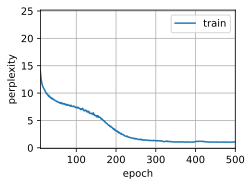

In [123]:
num_epochs, lr = 500, 1
train_ch8(net, train_iter, vocab, lr, num_epochs, device)

困惑度 1.5, 95622.2 词元/秒 mps
time travellerit s against reason said filbywhat leghen tho lith
travellerit s against reason said filbywhat leghen tho lith


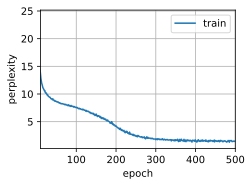

In [125]:
net = RNNModelScratch(len(vocab), num_hiddens, device, get_params,
init_rnn_state, rnn)
train_ch8(net, train_iter, vocab, lr, num_epochs, device,
use_random_iter=True)